<img src="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/imgs/banner_fcd.jpg?raw=1" alt="bannersp" width="1100"  height="150">

# <span style="color:#2F749F;"><strong>📦 Sesión práctica 3: Codificación y transformación de variables</strong></span>
---
<p align="right">
  <a href="https://colab.research.google.com/github/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_3_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>

## <span style="color:black;"><strong>Datos del estudiante</strong></span>

Estiven Ospina González y Juan José García Álvarez

## <span style="color:#2F749F;"><strong>Ejercicio 1: Comparación de métodos de escalamiento</strong></span>

A partir de un conjunto de datos real sobre **vinos**, analiza cómo cambia la escala de las variables al aplicar diferentes métodos de **escalamiento de datos**, y compara visualmente sus efectos sobre la distribución.

1. Carga el conjunto de datos **wine** desde la librería `sklearn.datasets` usando `load_wine()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `alcohol`
   - `malic_acid`
   - `color_intensity`

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - `StandardScaler`
   - `MinMaxScaler`
   - `RobustScaler`
   - `Z-Score`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **StandardScaler**
   - Distribución con **MinMaxScaler**
   - Distribución con **RobustScaler**
   - Distribución con **Z-Score**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

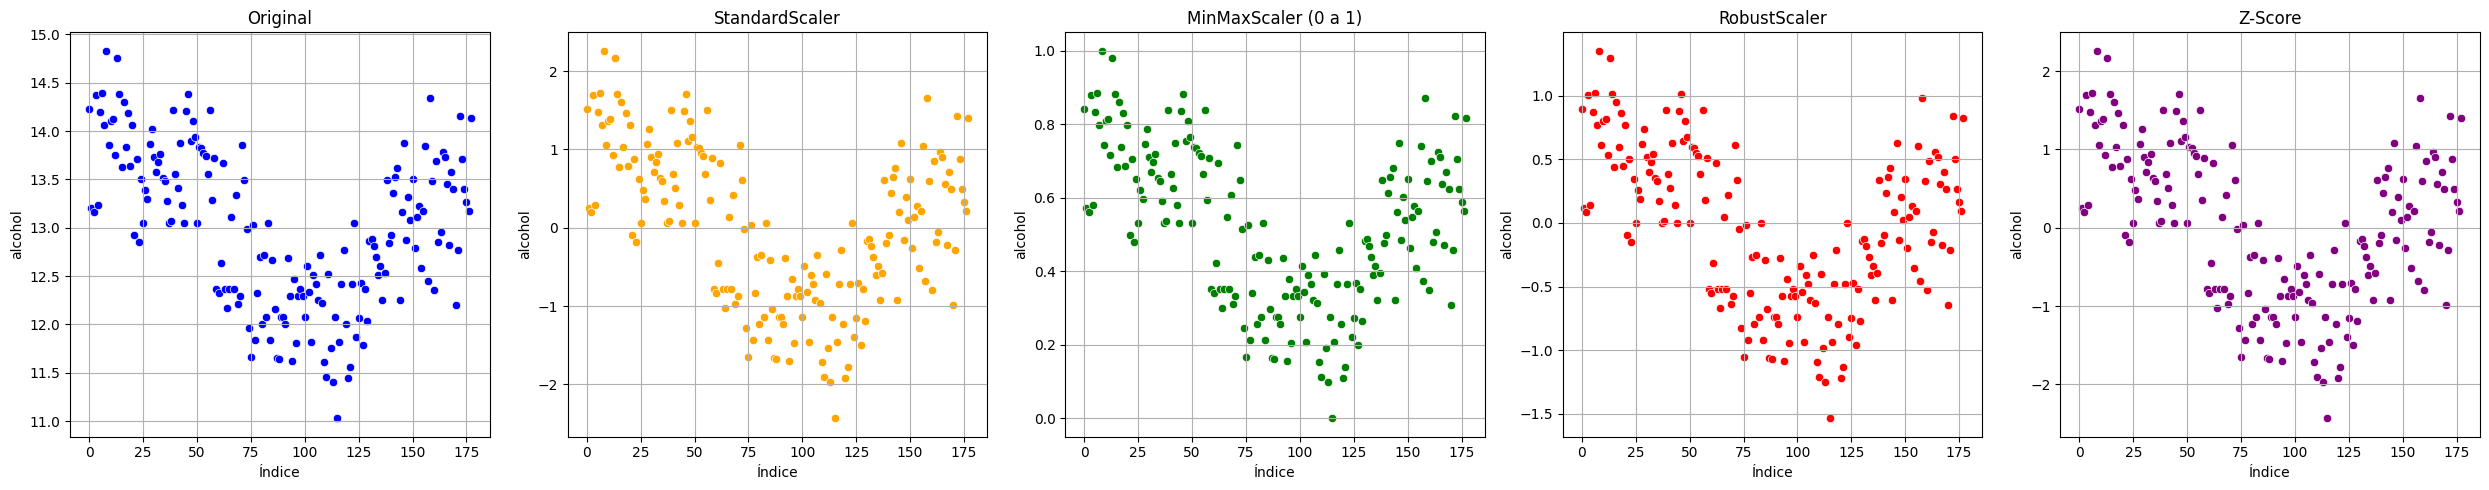

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

wine = load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
vars_seleccionadas = ['alcohol', 'malic_acid', 'color_intensity']
df_seleccion = df_wine[vars_seleccionadas]

# Escalamientos
df_standard = pd.DataFrame(StandardScaler().fit_transform(df_seleccion), columns=vars_seleccionadas)
df_minmax = pd.DataFrame(MinMaxScaler().fit_transform(df_seleccion), columns=vars_seleccionadas)
df_robust = pd.DataFrame(RobustScaler().fit_transform(df_seleccion), columns=vars_seleccionadas)
df_zscore = pd.DataFrame(stats.zscore(df_seleccion), columns=vars_seleccionadas)

# Gráficas
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
var_plot = 'alcohol'

sns.scatterplot(x=df_seleccion.index, y=df_seleccion[var_plot], ax=axes[0], color='blue').set_title('Original')
sns.scatterplot(x=df_standard.index, y=df_standard[var_plot], ax=axes[1], color='orange').set_title('StandardScaler')
sns.scatterplot(x=df_minmax.index, y=df_minmax[var_plot], ax=axes[2], color='green').set_title('MinMaxScaler (0 a 1)')
sns.scatterplot(x=df_robust.index, y=df_robust[var_plot], ax=axes[3], color='red').set_title('RobustScaler')
sns.scatterplot(x=df_zscore.index, y=df_zscore[var_plot], ax=axes[4], color='purple').set_title('Z-Score')
[a.set_xlabel('Índice') and a.grid(True) for a in axes]
plt.tight_layout()
plt.show()


### Análisis
Cada uno de los gráficos muestran que la forma de los datos sigue siendo exactamente la misma. La estandarización StandardScaler/Z-Score solo mueve los datos para que el promedio quede en cero. MinMaxScaler ajusta los valores para que el más alto sea 1 y el más bajo sea 0, comprimiendo todo dentro de ese rango. Por otro lado RobustScaler usa la mediana para que la mayoría de los datos se agrupen alrededor del origen, estabilizándolos e ignorando los datos atípicos, y es el motivo por el cual es el más recomendable en este caso.

## <span style="color:#2F749F;"><strong>Ejercicio 2: Comparación de escalamiento RobustScaler vs Z-Score</strong></span>

A partir de un conjunto de datos real sobre **diabetes**, analiza cómo cambia la escala de las variables al aplicar **estandarización con Z-Score** y **escalamiento robusto**, y compara visualmente sus efectos cuando existen **posibles valores atípicos**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo: `bmi`, `bp`, `s5` u otras disponibles en el dataset).

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - **StandardScaler** (Z-Score).
   - **RobustScaler** (basado en mediana e IQR).

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución **escalada con Z-Score**
   - Distribución **escalada con RobustScaler**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

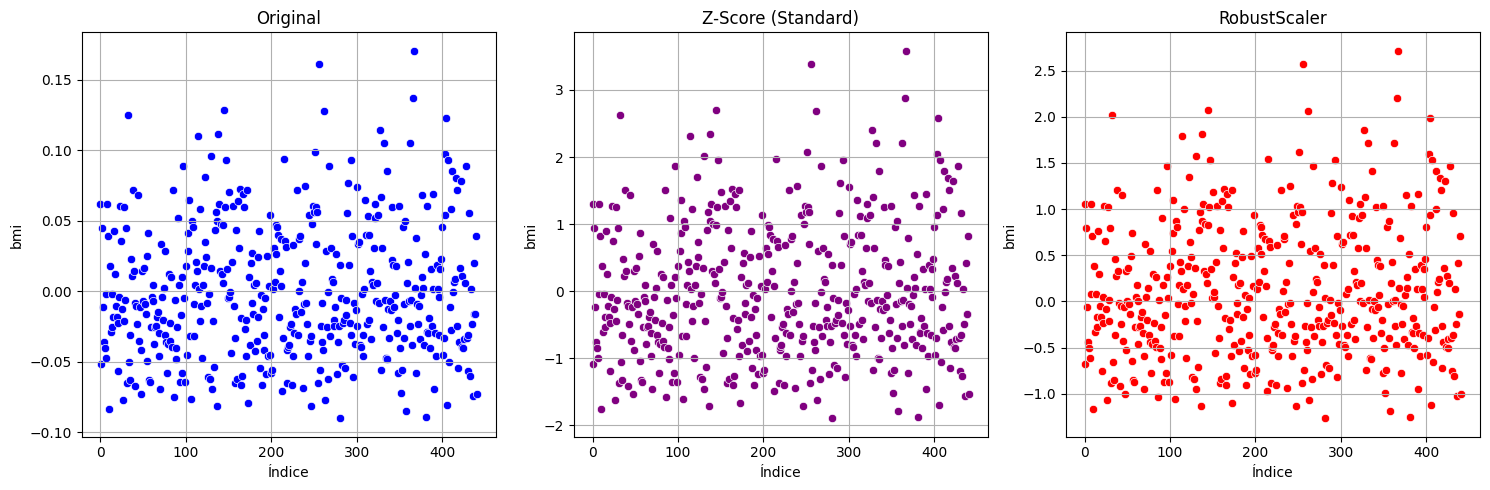

In [7]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
df_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
vars_diab = ['bmi', 'bp', 's5']
df_diab_sel = df_diabetes[vars_diab]

# Escalamientos
df_diab_zscore = pd.DataFrame(StandardScaler().fit_transform(df_diab_sel), columns=vars_diab)
df_diab_robust = pd.DataFrame(RobustScaler().fit_transform(df_diab_sel), columns=vars_diab)

# Gráficas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
var_plot = 'bmi'

sns.scatterplot(x=df_diab_sel.index, y=df_diab_sel[var_plot], ax=axes[0], color='blue').set_title('Original')
sns.scatterplot(x=df_diab_zscore.index, y=df_diab_zscore[var_plot], ax=axes[1], color='purple').set_title('Z-Score (Standard)')
sns.scatterplot(x=df_diab_robust.index, y=df_diab_robust[var_plot], ax=axes[2], color='red').set_title('RobustScaler')
[a.set_xlabel('Índice') and a.grid(True) for a in axes]
plt.tight_layout()
plt.show()


### Análisis
En este caso vemos que Z-Score usa la transformación de los datos para que tengan media 0 y desviación estándar 1, sin embargo se ve influenciada por outliers, que pueden desplazar o estirar los datos como se aprecia en la gráfica. Por otro lado, RobustScaler, como se vio en el ejercicio anterior, es más estable ante estos outliers, intenta no perjudicar al resto de los datos y muestra  más resistencia a este estiramiento. También es el más recomendable en este caso.

## <span style="color:#2F749F;"><strong>Ejercicio 3: Comparación de normalización L1 y L2</strong></span>

A partir de un conjunto de datos real sobre **precios de viviendas**, analiza cómo cambian los valores de las variables al aplicar **normalización L1 y L2**, y compara visualmente sus efectos sobre la distribución de los datos.

1. Carga el conjunto de datos **California Housing** desde la librería `sklearn.datasets` usando `fetch_california_housing()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `MedInc`
   - `AveRooms`
   - `HouseAge`

4. Aplica los siguientes métodos de **normalización** sobre las variables seleccionadas utilizando `Normalizer` de `sklearn.preprocessing`:
   - **Normalización L1**
   - **Normalización L2**

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **normalización L1**
   - Distribución con **normalización L2**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

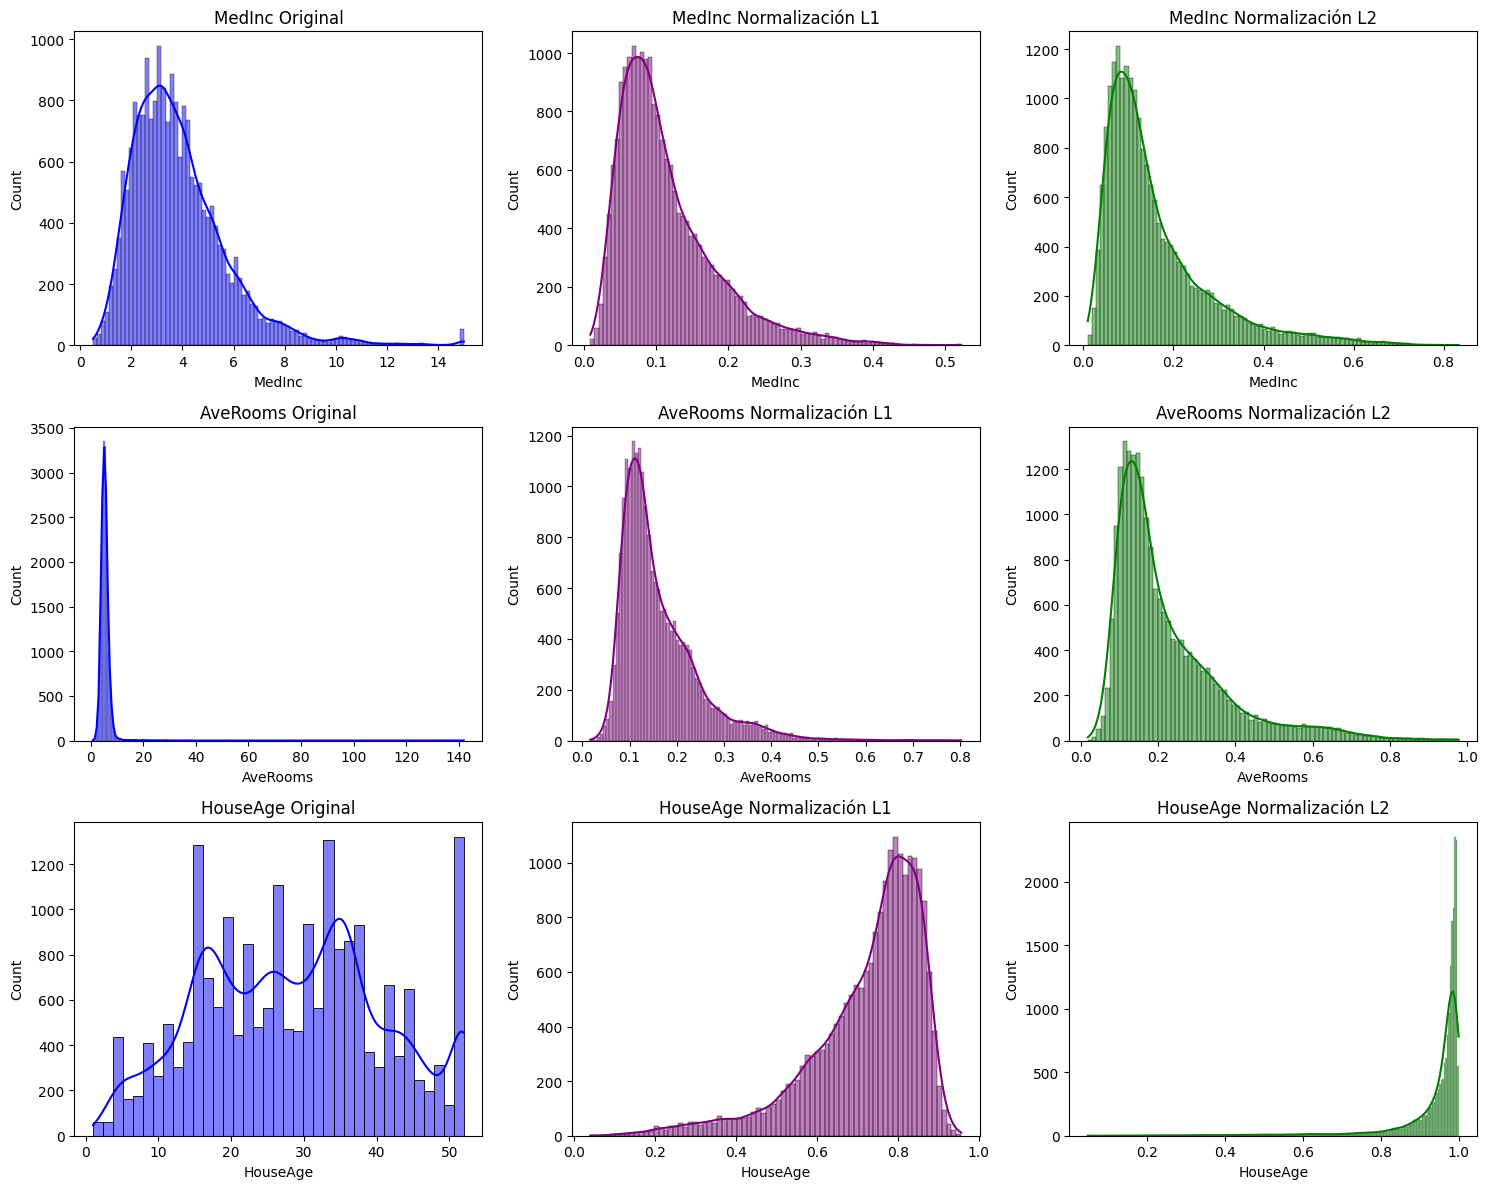

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import Normalizer

california = fetch_california_housing()
df_california = pd.DataFrame(california.data, columns=california.feature_names)

vars = ['MedInc', 'AveRooms', 'HouseAge']
df_subset = df_california[vars]

# Normalización L1 y L2
norm_l1 = Normalizer(norm='l1')
norm_l2 = Normalizer(norm='l2')

df_l1 = pd.DataFrame(norm_l1.fit_transform(df_subset), columns=vars)
df_l2 = pd.DataFrame(norm_l2.fit_transform(df_subset), columns=vars)

# Gráficas comparativas
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, var in enumerate(vars):
    sns.histplot(df_subset[var], kde=True, ax=axes[i, 0], color='blue').set_title(f'{var} Original')
    sns.histplot(df_l1[var], kde=True, ax=axes[i, 1], color='purple').set_title(f'{var} Normalización L1')
    sns.histplot(df_l2[var], kde=True, ax=axes[i, 2], color='green').set_title(f'{var} Normalización L2')

plt.tight_layout()
plt.show()

### Análisis
Las normalizaciones L1 y L2 actúan a nivel de fila, dividiendo los valores por la suma de valores absolutos o su magnitud vectorial, lo que afecta sus distribuciones y sus rangos de datos como se puede ver en las gráficas. Es útil usarlas cuando la magnitud no es tan importante pero la proporción sí. En este caso específico no es tan recomendable usarlas ya que se mezclan unidades distintas como edad, ingresos y cuartos. Sería más apropiado usar escalado por columna como en los ejercicios anteriore.

## <span style="color:#2F749F;"><strong>Ejercicio 4: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con diabetes**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo: `bmi`, `bp` o `s5`).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Transformación logarítmica** usando `np.log()` o `np.log1p()`
   - **Transformación logarítmica reflejada** (útil cuando existe asimetría negativa)
   - **Transformación cuadrática** usando `x²`
   - **Transformación Box-Cox** usando `scipy.stats.boxcox`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación log**
   - Distribución con **log reflejado**
   - Distribución con **transformación cuadrática**
   - Distribución con **transformación Box-Cox**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

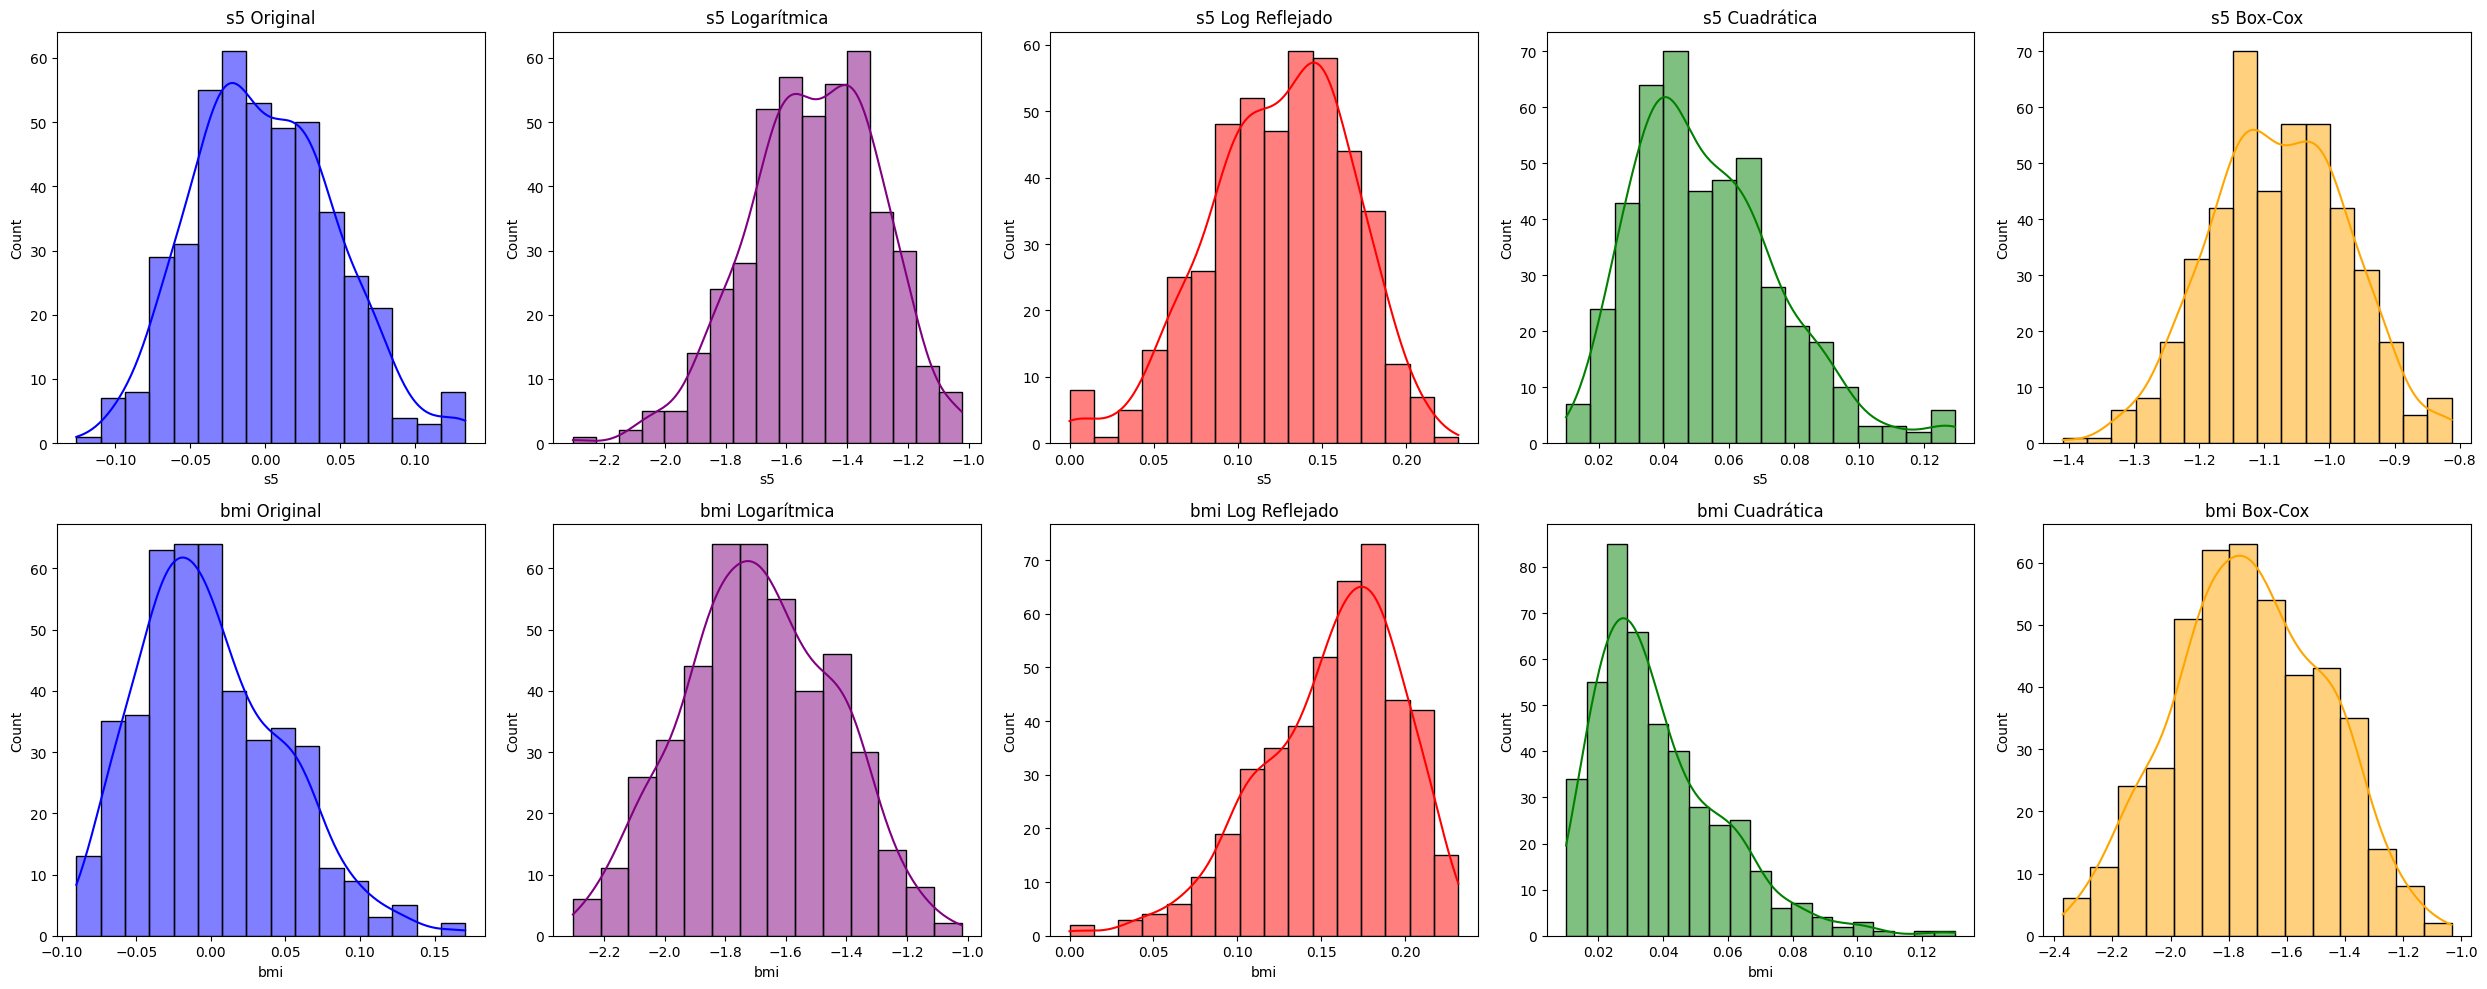

In [24]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
df_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

vars_ej4 = ['s5', 'bmi']

fig, axes = plt.subplots(2, 5, figsize=(25, 10))

for i, var in enumerate(vars_ej4):
    
    # Dado que logaritmo y Box-Cox requieren números estrictamente positivos, creamos un offset para trasladar la curva un escalón arriba ya que sklearn trae estos datasets pre-estandarizados (con negativos).
    offset = abs(df_diabetes[var].min()) + 0.1 
    datos_positivos = df_diabetes[var] + offset

    # Transformaciones:
    trans_log = np.log(datos_positivos)
    trans_log_ref = np.log(datos_positivos.max() - datos_positivos + 1)
    trans_cuadratica = datos_positivos ** 2
    trans_boxcox, _ = stats.boxcox(datos_positivos) 

    # Gráficas comparativas por cada variable (s5 -> fila 0, bmi -> fila 1)
    sns.histplot(df_diabetes[var], kde=True, ax=axes[i, 0], color='blue').set_title(f'{var} Original')
    sns.histplot(trans_log, kde=True, ax=axes[i, 1], color='purple').set_title(f'{var} Logarítmica')
    sns.histplot(trans_log_ref, kde=True, ax=axes[i, 2], color='red').set_title(f'{var} Log Reflejado')
    sns.histplot(trans_cuadratica, kde=True, ax=axes[i, 3], color='green').set_title(f'{var} Cuadrática')
    sns.histplot(trans_boxcox, kde=True, ax=axes[i, 4], color='orange').set_title(f'{var} Box-Cox')

plt.tight_layout()
plt.show()


### Análisis
De las gráficas se puede ver que transformaciones como la logarítmica son buenas para reducir la asimetría a la derecha, en ambos casos. La Log reflejado cumple con encontrar una simetría en s5, pero en bmi básicamente refleja la asimetría, por lo que no es tan recomendable. Por otro lado, la cuadrática hace que se amplifique la asimetría existente. Por último, la transformación de Box-Cox resultó la más recomendable ya que encuentra matemáticamente el parámetro óptimo para forzar los datos hacia una distribución normal, que cumple con eliminar o reducir esa asimetría inicial.

## <span style="color:#2F749F;"><strong>Ejercicio 5: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con enfermedades cardíacas**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos **Heart Disease** desde la librería `ucimlrepo` usando `load_dataset("heart_disease = fetch_ucirepo(id=45)")`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo:  
   - `chol` (colesterol)  
   - `trestbps` (presión arterial en reposo)  
   - `thalach` (frecuencia cardíaca máxima)).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Raíz cuadrada** usando `np.sqrt()`  
   - **Recíproca** usando `1/x`  
   - **Transformación Yeo-Johnson** usando `PowerTransformer(method="yeo-johnson")`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación raíz cuadrada**
   - Distribución con **transformación recíproca**
   - Distribución con **transformación Yeo-Johnson**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

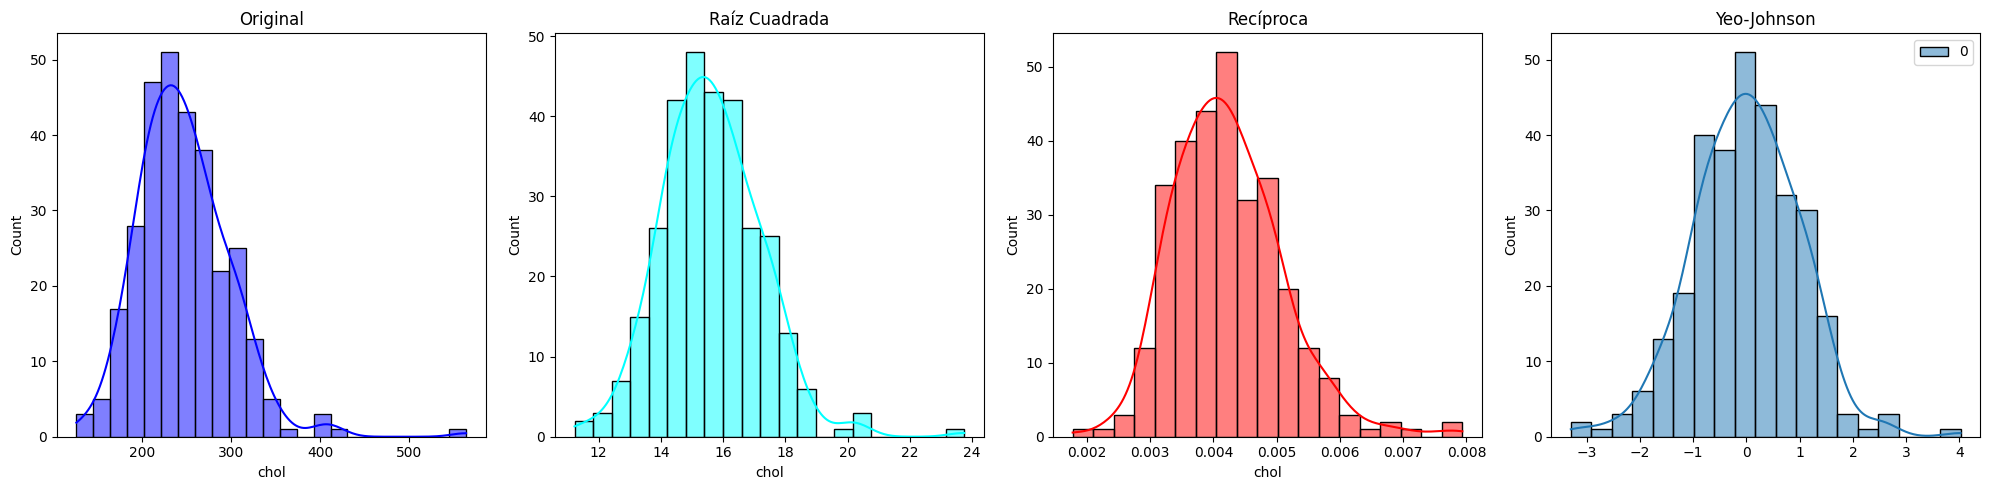

In [25]:
from ucimlrepo import fetch_ucirepo 
from sklearn.preprocessing import PowerTransformer

heart_disease = fetch_ucirepo(id=45) 
df_heart = pd.DataFrame(heart_disease.data.features)

var_h = 'chol'

df_heart.dropna(subset=[var_h], inplace=True)
data_chol = df_heart[var_h]

# Transformaciones

# Raíz Cuadrada
trans_raiz = np.sqrt(data_chol)
# Recíproca
trans_reciproca = 1 / data_chol
# Yeo-Johnson
pt = PowerTransformer(method='yeo-johnson')
trans_yeo = pt.fit_transform(df_heart[[var_h]])

# Generar gráficas
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
sns.histplot(data_chol, kde=True, ax=axes[0], color='blue').set_title('Original')
sns.histplot(trans_raiz, kde=True, ax=axes[1], color='cyan').set_title('Raíz Cuadrada')
sns.histplot(trans_reciproca, kde=True, ax=axes[2], color='red').set_title('Recíproca')
sns.histplot(trans_yeo, kde=True, ax=axes[3], color='green').set_title('Yeo-Johnson')

plt.tight_layout()
plt.show()


### Análisis
En este último ejercicio se puede observar que la raíz cuadrada corrige levemente la asimetría, pero no es suficiente porque igual la mantiene, similar a lo que pasa con la recíproca, que es muy agresiva para datos muy sesgados, en este caso no da tan buenos resultados. La técnica de Yeo-Johnson es la más recomendada en este caso como se puede ver en la gráfica, y en general en flujos de datos modernos. Es una extensión de la Box-Cox, pero a diferencia de esta, y lo que la hace mejor, es que acepta valores de 0 o negativos, e igualmente logra una estandarización de tipo normal / gaussiana.